In [ ]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix

from pandas_profiling import ProfileReport


import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('c:/Users/layel/Downloads/Market_Basket_Optimisation.csv')  # Replace with your dataset path


C:\Users\layel\AppData\Local\Temp\ipykernel_7944\2279043369.py:16: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


In [ ]:
data_filled = data.fillna('None')

data_numeric = pd.get_dummies(data_filled)

print(data_numeric.shape)


(7500, 1281)


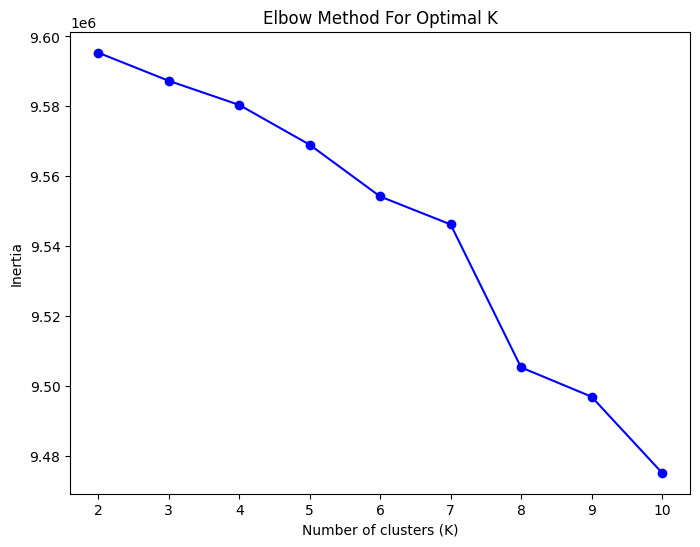

Cluster
1    7496
2       2
0       1
3       1
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data_filled = data.fillna('None')
data_numeric = pd.get_dummies(data_filled)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_numeric)


inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.show()

optimal_k = 4  
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters
print(data['Cluster'].value_counts())


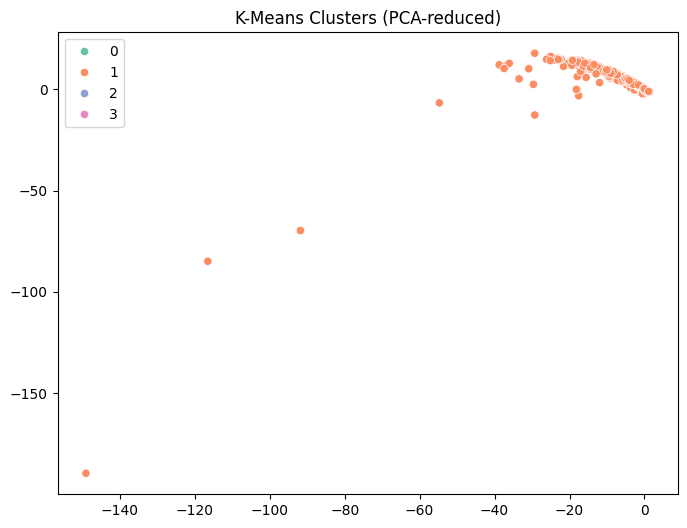

In [11]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set2')
plt.title('K-Means Clusters (PCA-reduced)')
plt.show()
